# Model Fitness: Customer Churn Analysis

## Introduction

Customer retention is an important challenge for fitness centers because losing members can reduce recurring revenue and increase the cost of acquiring new customers. Understanding which clients are more likely to cancel their memberships can help a gym design more effective retention strategies and improve the customer experience.

This project analyzes customer data from Model Fitness, a gym chain seeking to better understand membership churn. The dataset contains 4,000 customer records and 14 variables related to demographics, membership characteristics, location, promotional programs, group class participation, visit frequency, additional spending, and customer lifetime.

The main objective is to identify the factors associated with customer churn and develop analytical models that can help predict which members are at greater risk of leaving. The analysis will compare the characteristics and behavior of customers who remained active with those who canceled their memberships.

The project will include exploratory data analysis, customer behavior comparisons, correlation analysis, predictive modeling, and customer segmentation. Logistic Regression and Random Forest models will be evaluated to predict churn, while clustering techniques will be used to identify groups of customers with similar characteristics.

The final results will support data-driven recommendations for improving customer retention, strengthening engagement, and identifying high-risk customer profiles before they cancel their memberships.

## Project Objectives

- Examine the structure and quality of the customer dataset.
- Compare active customers with customers who churned.
- Identify behavioral and membership characteristics associated with churn.
- Analyze correlations between customer attributes and cancellation behavior.
- Build and evaluate classification models to predict customer churn.
- Segment customers into groups based on common characteristics.
- Develop practical recommendations to improve customer retention.

## Dataset Description

Each row in the dataset represents a customer of Model Fitness. The dataset contains the following variables:

- `gender`: Customer gender, represented as a binary value.
- `Near_Location`: Indicates whether the customer lives or works near the gym.
- `Partner`: Indicates whether the customer works for a partner company.
- `Promo_friends`: Indicates whether the customer joined through a friend referral promotion.
- `Phone`: Indicates whether the customer provided a phone number.
- `Contract_period`: Duration of the customer’s membership contract in months.
- `Group_visits`: Indicates whether the customer participates in group classes.
- `Age`: Customer age.
- `Avg_additional_charges_total`: Average amount spent on additional gym services.
- `Month_to_end_contract`: Number of months remaining in the current membership contract.
- `Lifetime`: Number of months since the customer’s first visit.
- `Avg_class_frequency_total`: Average weekly class attendance over the customer’s full membership period.
- `Avg_class_frequency_current_month`: Average weekly class attendance during the current month.
- `Churn`: Target variable indicating whether the customer canceled the membership, where `1` represents churn and `0` represents an active customer.

In [1]:
%pip install scikit-learn
%pip install pandas numpy matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading and Initial Inspection

In [2]:
# Main libraries
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model preparation and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Clustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

# Visual configuration
sns.set(style="whitegrid")

In [3]:
# Load the dataset
gym = pd.read_csv("gym_churn_us.csv")

# Display the dataset dimensions
print(f"Rows: {gym.shape[0]:,}")
print(f"Columns: {gym.shape[1]}")

# Display the first rows
gym.head()

Rows: 4,000
Columns: 14


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


The dataset contains 4,000 observations and 14 columns. Each row represents a gym customer and includes demographic information, membership characteristics, gym usage behavior, and the target variable `Churn`, which indicates whether the customer canceled the membership.

A preliminary review shows that all variables are stored in numeric format. Several columns represent binary categories, while the remaining variables contain discrete or continuous numerical values. Therefore, no categorical encoding is required before beginning the exploratory analysis.

### 2. Exploratory Data Analysis — EDA
2.1 General Information and Missing Values

In [4]:
# Display general information about the dataset
gym.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

In [5]:
# Check the number of missing values in each column
missing_values = gym.isna().sum()

missing_values

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

The dataset contains no missing values, since all 14 columns include 4,000 non-null observations. This allows the analysis to continue without imputing values or removing incomplete records.

All variables are numerical. Some of them are binary indicators, including `gender`, `Near_Location`, `Partner`, `Promo_friends`, `Phone`, `Group_visits`, and `Churn`.

The remaining variables are continuous or discrete numerical features, such as `Age`, `Lifetime`, `Contract_period`, `Month_to_end_contract`, `Avg_class_frequency_total`, and `Avg_class_frequency_current_month`.

In [6]:
# Estadísticas descriptivas
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


Las estadísticas descriptivas muestran que el perfil promedio del cliente tiene aproximadamente 29 años, vive o trabaja cerca del gimnasio en la mayoría de los casos y tiene una frecuencia media de visitas cercana a 1.9 veces por semana.

El periodo promedio de contrato es de 4.68 meses, aunque la mediana es de 1 mes, lo cual indica que una parte importante de los usuarios tiene contratos cortos. El tiempo promedio desde la primera visita (`Lifetime`) es de 3.72 meses, por lo que muchos clientes aún se encuentran en una etapa temprana de relación con el gimnasio.

También se observa que aproximadamente el 41% de los clientes participa en clases grupales y cerca del 49% trabaja en una empresa asociada. Estos factores pueden ser relevantes para analizar la retención.

### 2.2 Average Values by Churn Status

In this section, we compare customers who remained active with customers who canceled their memberships.

In [7]:
# Transpose the table to make the comparison easier to read
churn_comparison = (
    gym.groupby("Churn")
    .mean()
    .T
    .rename(columns={
        0: "Stayed",
        1: "Churned"
    })
)

churn_comparison

Churn,Stayed,Churned
gender,0.510037,0.510839
Near_Location,0.873086,0.768143
Partner,0.534195,0.355325
Promo_friends,0.353522,0.183789
Phone,0.903709,0.902922
Contract_period,5.747193,1.728558
Group_visits,0.464103,0.268615
Age,29.976523,26.989632
Avg_additional_charges_total,158.445715,115.082899
Month_to_end_contract,5.283089,1.662582


The comparison between customers who remained active and those who churned reveals several clear differences.

Customers who canceled their memberships had considerably shorter contract periods. Their average `Contract_period` was approximately 1.73 months, compared with 5.75 months among customers who remained active.

Similarly, churned customers had fewer months remaining on their contracts and a much shorter average `Lifetime`, close to 1 month, compared with approximately 4.71 months for customers who stayed.

Customers who churned also attended classes less frequently. Their average class attendance was approximately 1.47 visits per week, compared with 2.02 visits among active customers. This suggests that attendance frequency may be one of the most important indicators of customer retention..

In addition, customers who remained active showed higher participation in group classes, a greater likelihood of being associated with partner companies, and higher average spending on additional services. These characteristics suggest a stronger level of engagement with the gym.

2.3 Variable Distributions by Churn Group

In [8]:
# Separate customers who stayed from customers who churned
stayed = gym[gym["Churn"] == 0]
churned = gym[gym["Churn"] == 1]

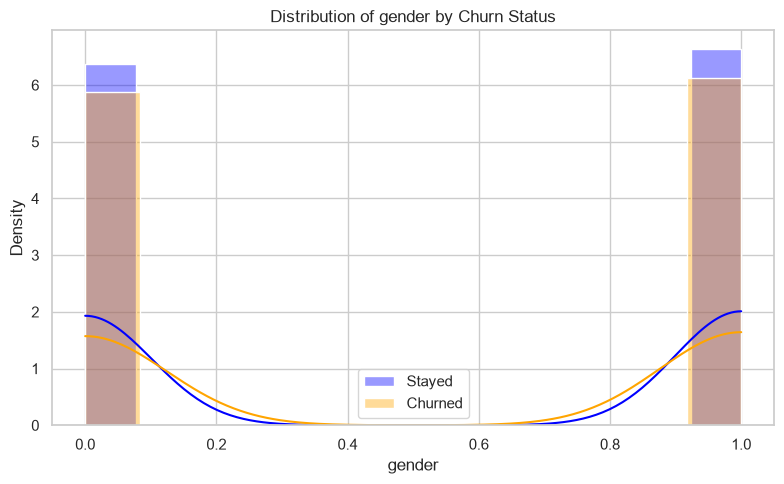

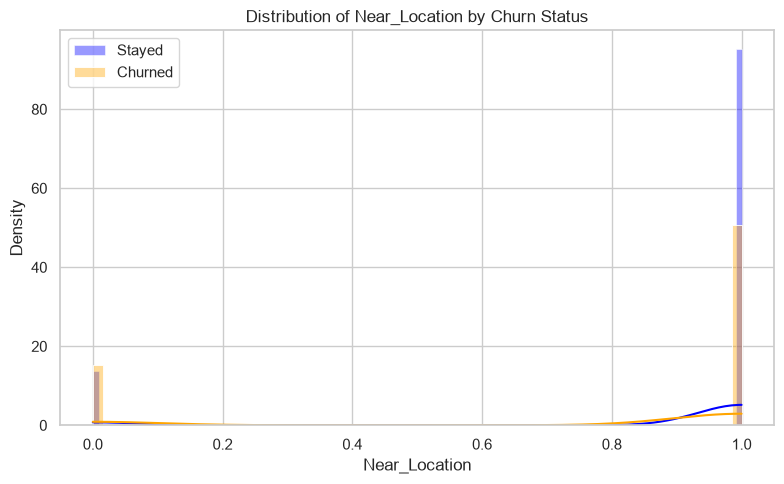

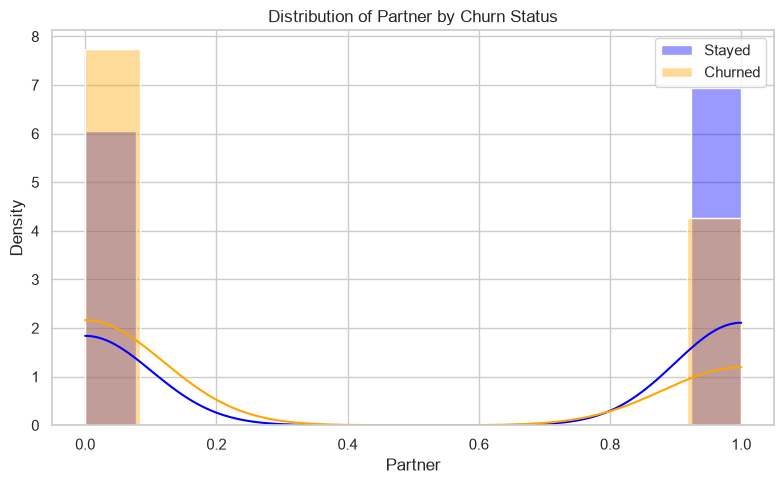

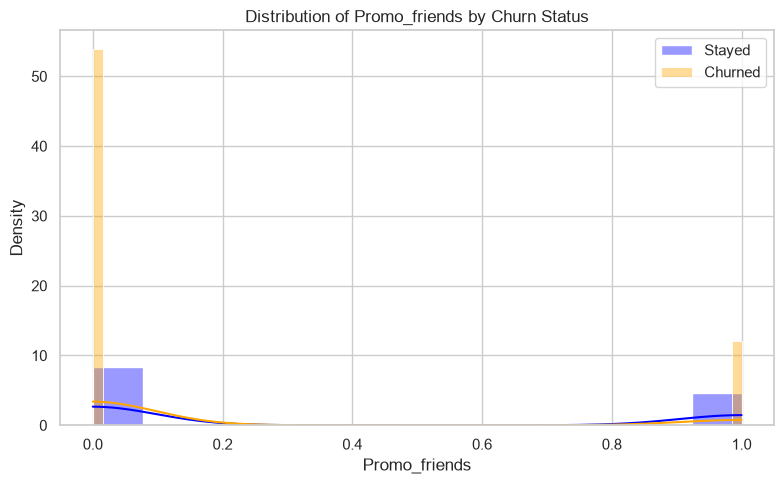

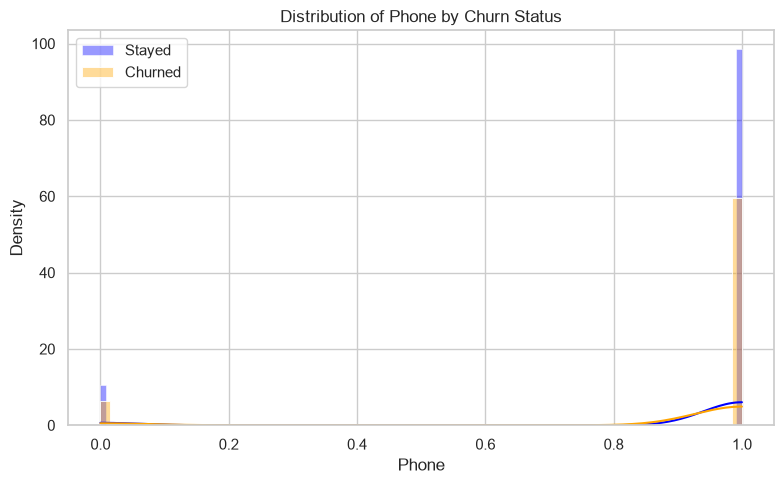

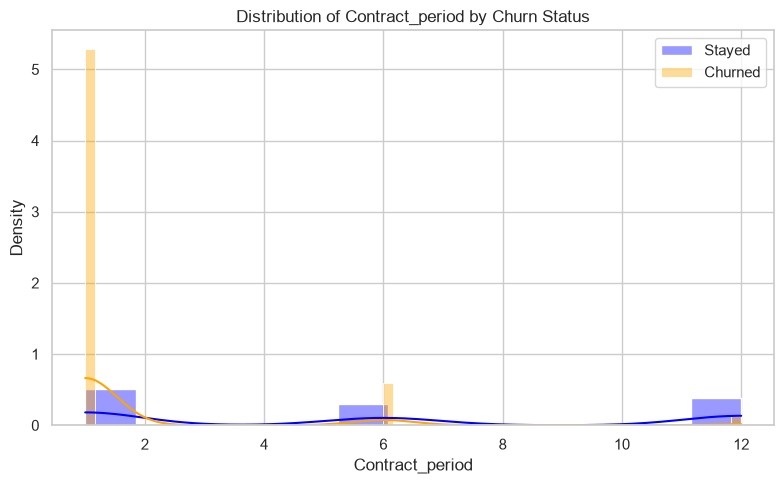

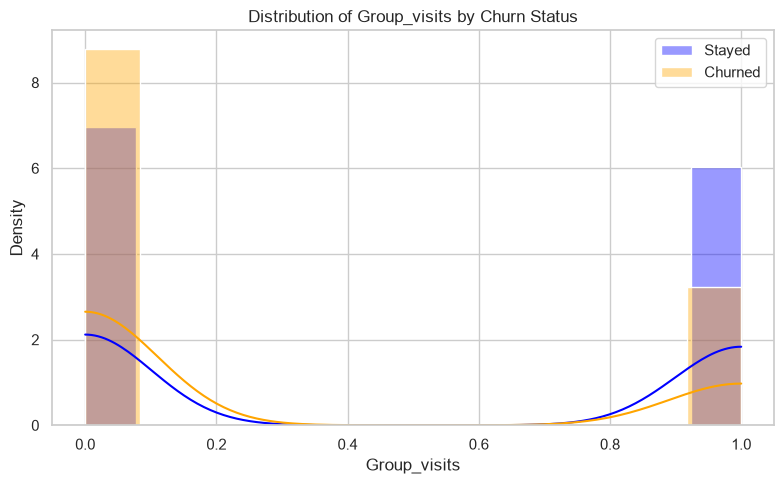

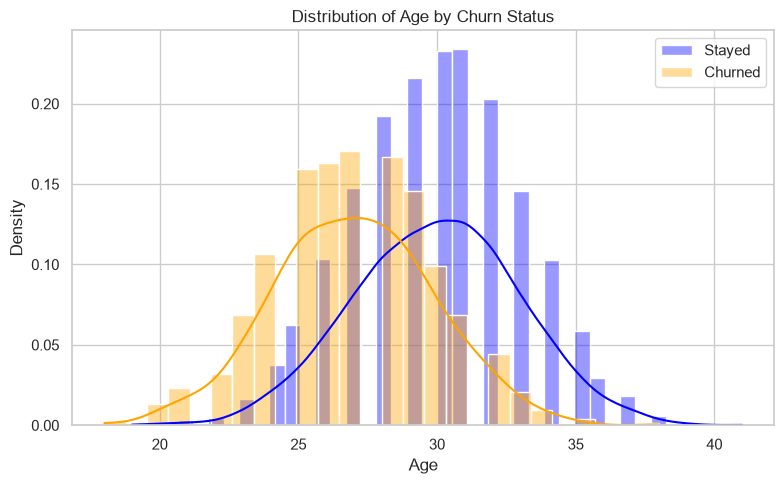

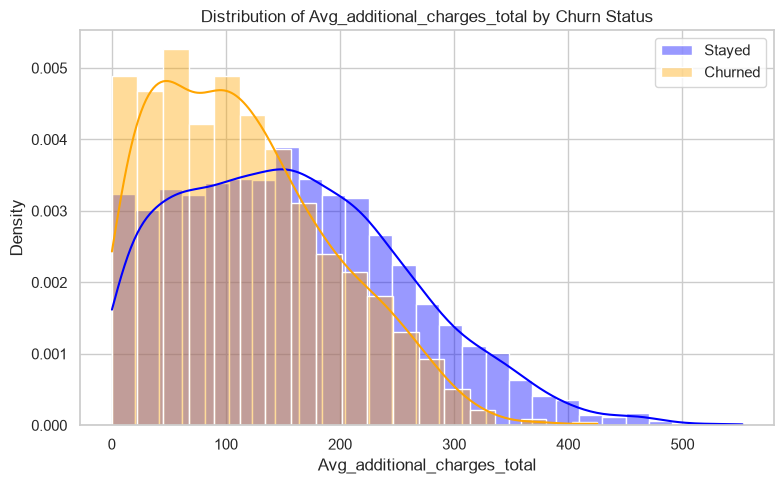

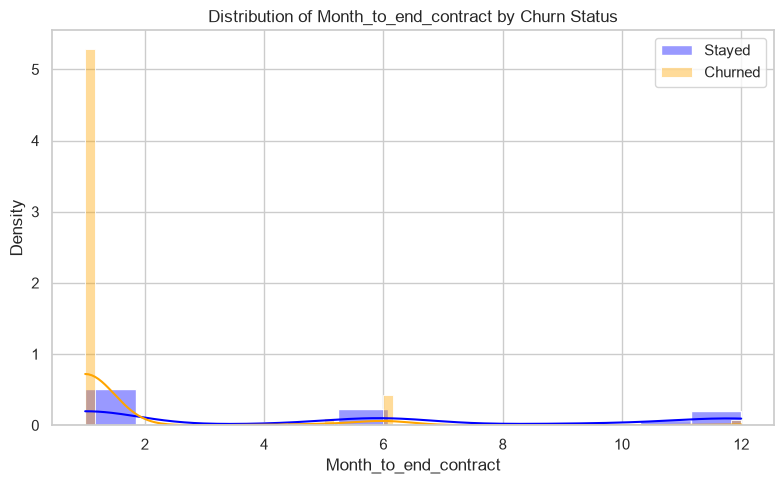

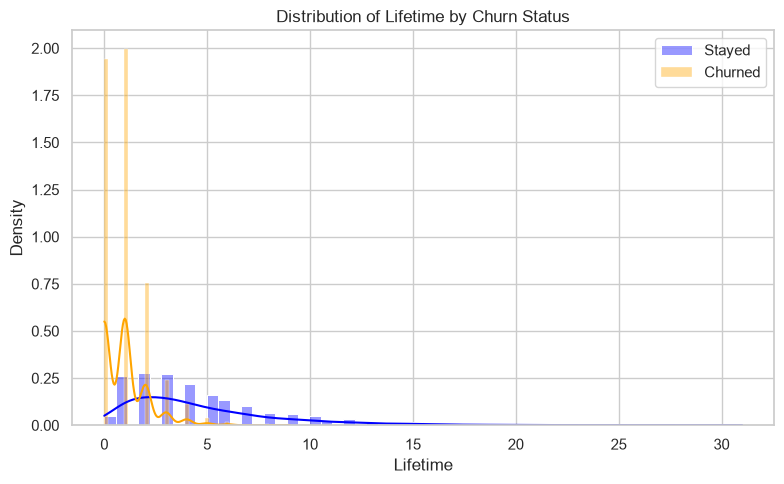

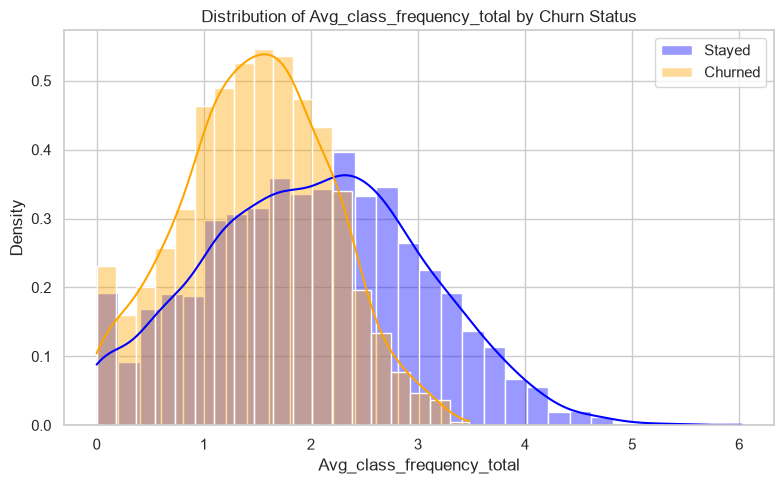

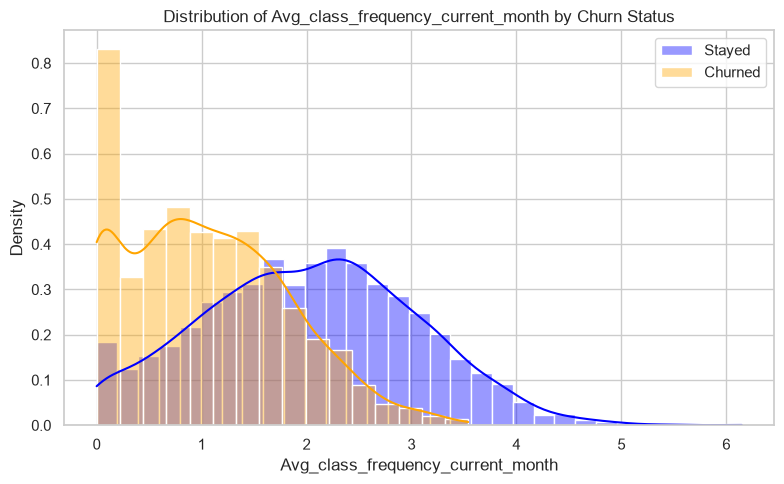

In [9]:
# Plot the distribution of each variable by churn status
features = gym.drop(columns="Churn").columns

for column in features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=stayed,
        x=column,
        color="blue",
        label="Stayed",
        kde=True,
        stat="density",
        alpha=0.4
    )

    sns.histplot(
        data=churned,
        x=column,
        color="orange",
        label="Churned",
        kde=True,
        stat="density",
        alpha=0.4
    )

    plt.title(
        f"Distribution of {column} by Churn Status"
    )
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

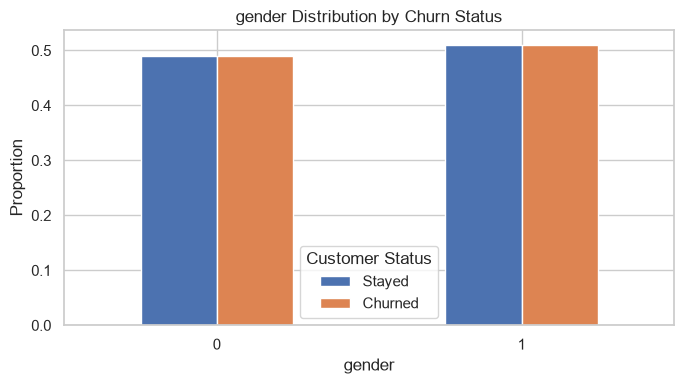

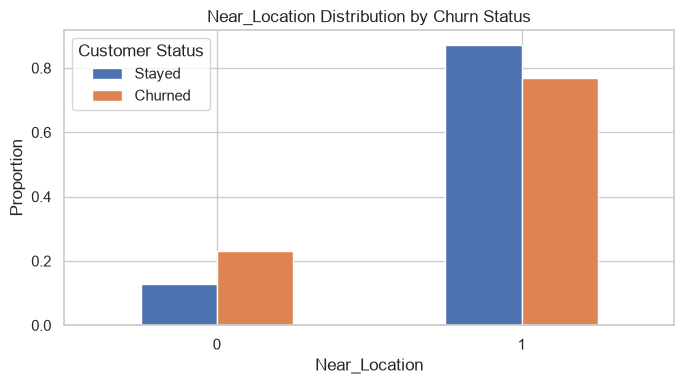

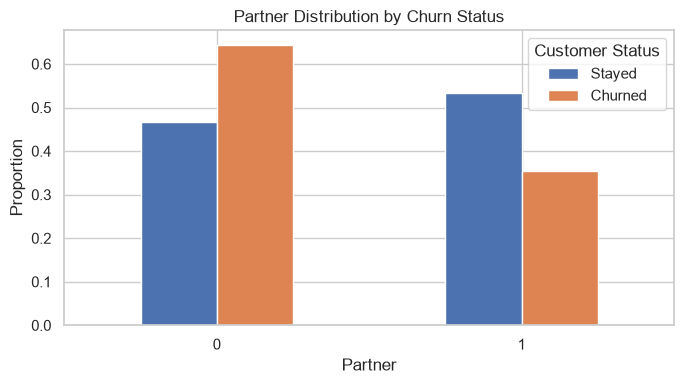

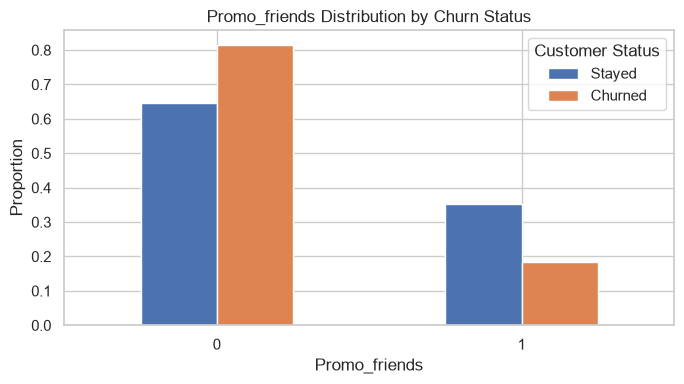

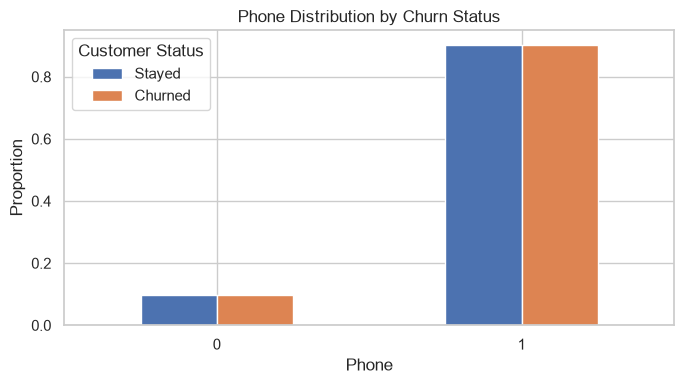

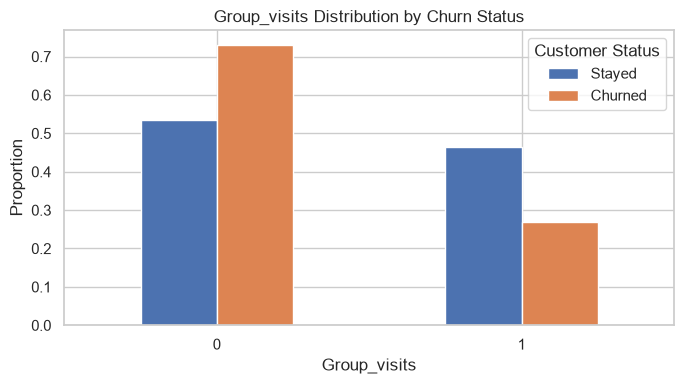

In [10]:
# Binary variables included in the dataset
binary_columns = [
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Group_visits"
]

for column in binary_columns:
    proportions = pd.crosstab(
        gym[column],
        gym["Churn"],
        normalize="columns"
    )

    proportions.columns = [
        "Stayed",
        "Churned"
    ]

    proportions.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(
        f"{column} Distribution by Churn Status"
    )
    plt.xlabel(column)
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.legend(title="Customer Status")
    plt.tight_layout()
    plt.show()

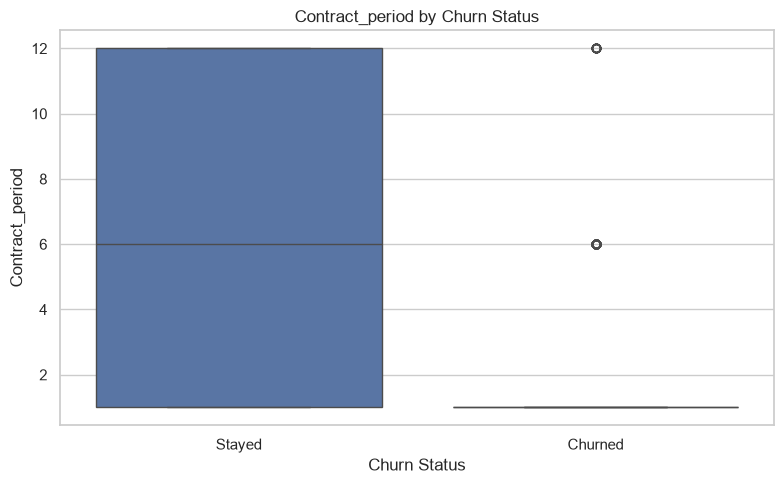

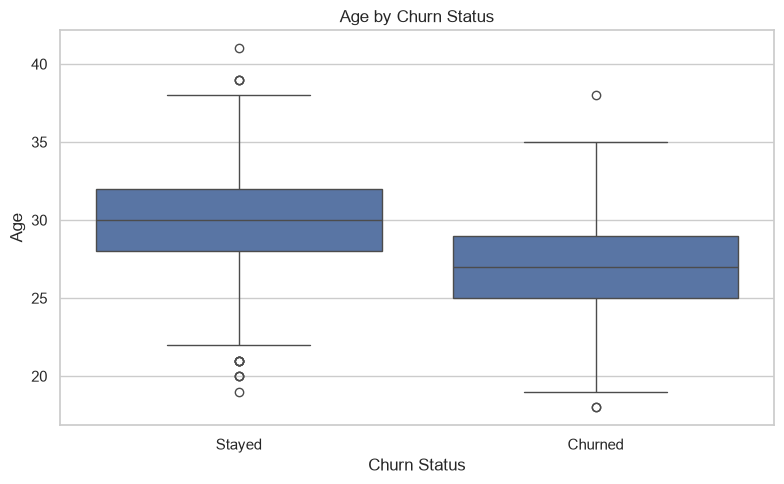

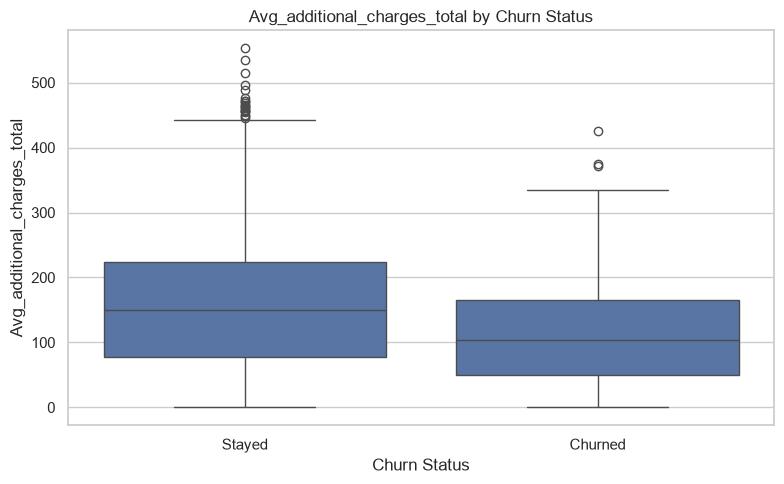

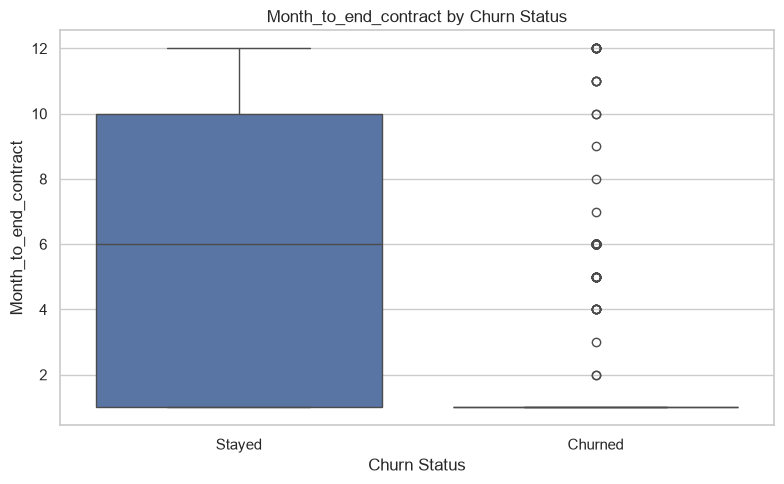

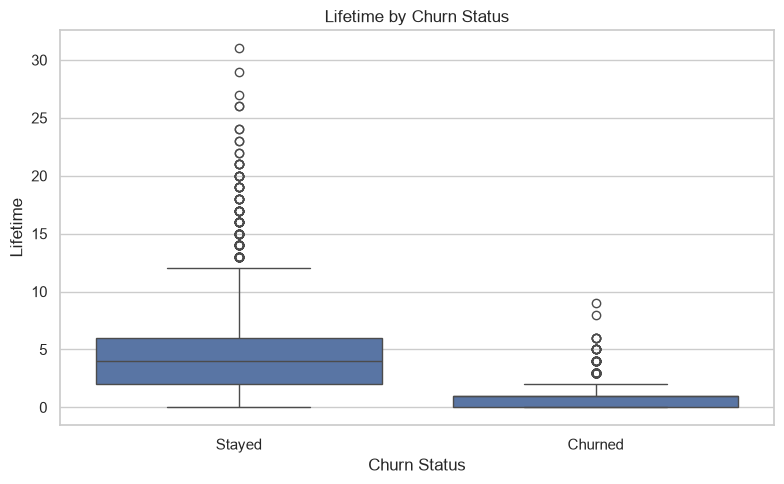

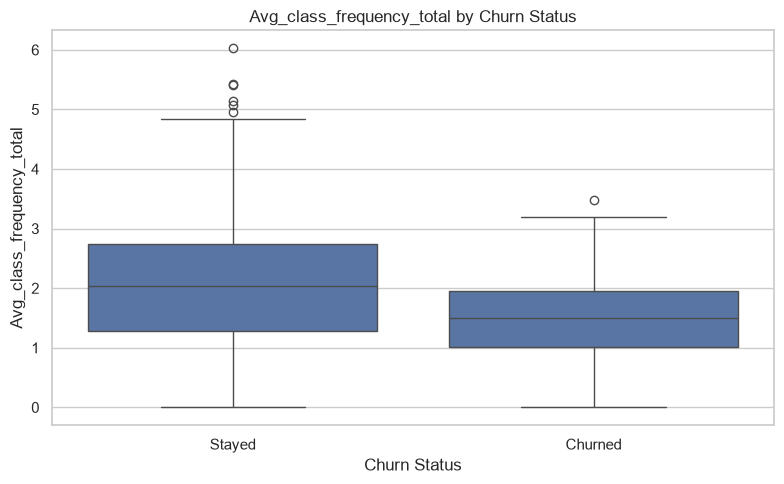

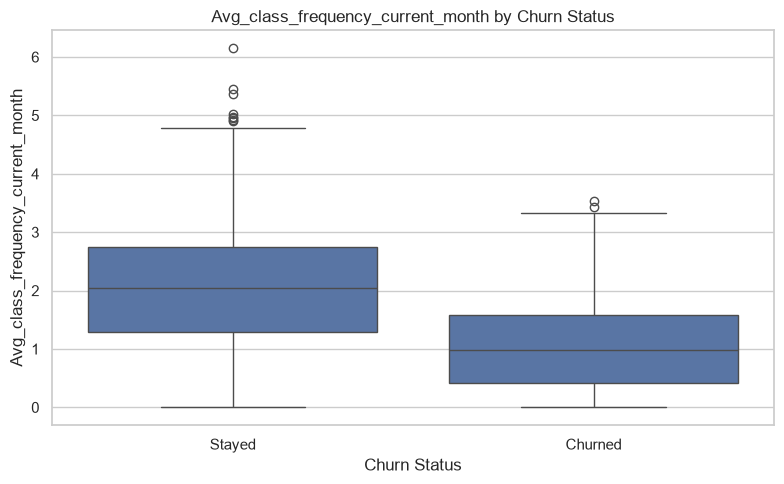

In [11]:
# Continuous and discrete numerical variables
numerical_columns = [
    "Contract_period",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month"
]

for column in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=gym,
        x="Churn",
        y=column
    )

    plt.title(
        f"{column} by Churn Status"
    )
    plt.xlabel("Churn Status")
    plt.ylabel(column)
    plt.xticks(
        ticks=[0, 1],
        labels=["Stayed", "Churned"]
    )
    plt.tight_layout()
    plt.show()

### General Interpretation of Variable Distributions by Churn Status

The distribution charts show clear behavioral and membership differences between customers who remained active and those who churned.

Demographic variables such as `gender` show almost identical distributions across both groups, suggesting that gender is not a relevant factor for explaining churn. The `Phone` variable also shows very little variation between active and churned customers, so it is unlikely to provide meaningful predictive value.

In contrast, several membership-related variables show noticeable differences. Customers who churned were much more concentrated in one-month contracts, while customers who stayed were more evenly distributed across longer contract periods, including six- and twelve-month memberships. This indicates that short-term contracts are strongly associated with a higher probability of cancellation.

The binary-variable comparisons also show that churned customers were less likely to live or work near the gym, participate in group classes, join through a friend referral, or be associated with a partner company. These factors may reflect lower engagement or weaker integration into the gym community.

Age also differs between the two groups. Customers who stayed were generally older, with the distribution centered around 30 years, while churned customers were more concentrated in the mid-to-late twenties.

The strongest behavioral differences are visible in attendance frequency. Active customers attended classes more frequently both over their full membership period and during the current month. Churned customers were concentrated at lower attendance levels, with many showing little or no recent activity. The difference is especially clear for `Avg_class_frequency_current_month`, suggesting that a decline in recent attendance may be an important early warning indicator of churn.

Customer lifetime also shows a strong contrast. Churned customers were heavily concentrated within the first months of membership, while active customers generally had longer relationships with the gym. This suggests that the early stage of the customer lifecycle is a critical period for retention.

Active customers also tended to spend more on additional services, although the distributions overlap considerably. This variable may contribute to churn prediction, but it appears less influential than attendance frequency, contract duration, and customer lifetime.

Overall, the distributions suggest that churn is primarily associated with customer engagement and membership structure rather than demographic characteristics. Customers at greater risk of cancellation tend to have shorter contracts, lower recent attendance, shorter lifetimes, less participation in group activities, and weaker connections to partner or referral programs.


2.4 Correlation Matrix

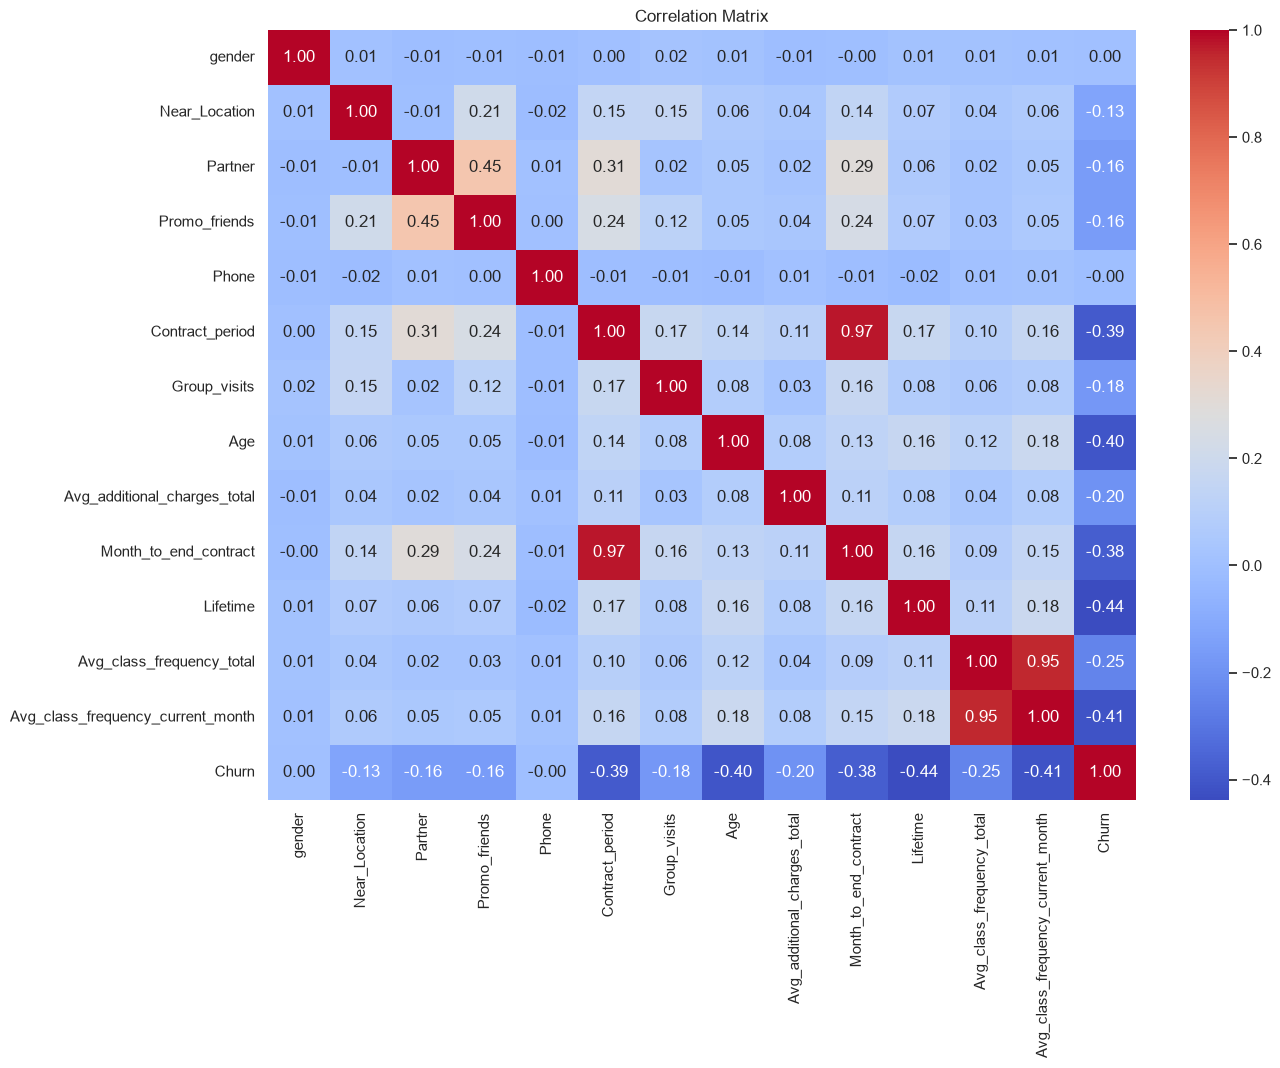

In [12]:
# Correlation Matrix
corr_matrix = gym.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Correlation Matrix Interpretation

The correlation matrix provides an initial overview of which variables are most strongly associated with customer churn and which features may contain overlapping information.

In general, most variables show a negative correlation with `Churn`, meaning that higher values are usually associated with a lower probability of cancellation.

The strongest negative relationships with churn are observed in:

- `Lifetime` (-0.44)
- `Avg_class_frequency_current_month` (-0.41)
- `Age` (-0.40)
- `Contract_period` (-0.39)
- `Month_to_end_contract` (-0.38)
- `Avg_class_frequency_total` (-0.25)

These results suggest that customers who have been members for a longer period, attend classes more frequently, are older, and have longer contracts are less likely to cancel their memberships.

The matrix also reveals two very strong relationships between predictor variables. `Contract_period` and `Month_to_end_contract` have a correlation of approximately 0.97, while `Avg_class_frequency_total` and `Avg_class_frequency_current_month` have a correlation of approximately 0.95.

These high correlations are expected because each pair measures closely related aspects of the customer relationship. However, they may introduce multicollinearity in models such as Logistic Regression, so this should be considered during the modeling stage.

Other variables, including `gender`, `Phone`, `Promo_friends`, `Group_visits`, and `Avg_additional_charges_total`, show weaker linear relationships with churn. This does not necessarily mean that they have no predictive value, since they may still contribute when combined with other features.

Overall, the correlation matrix supports the previous findings: customer retention is mainly associated with membership duration, contract length, recent attendance, overall attendance frequency, and age.


### 3. Churn Prediction Model
3.1 Separate Features and Target Variable

In [13]:
# Feature matrix and target variable
X = gym.drop("Churn", axis=1)
y = gym["Churn"]

In [14]:
# Split the data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

At this stage, the target variable `Churn` was separated from the remaining customer features.

The data was then divided into training and validation sets using an 80/20 split. The training set will be used to fit the classification models, while the validation set will be used to evaluate their performance on data that was not seen during training.

The `stratify=y` parameter preserves the original churn distribution in both datasets, which helps ensure a more reliable comparison between the models.

3.2 Standardize the Features

Feature standardization is recommended for Logistic Regression because the model can be affected by differences in the scale of the input variables.

In [15]:
# Create and fit the scaler using only the training data
scaler = StandardScaler()
scaler.fit(X_train)

# Transform the training and validation features
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

Before training the Logistic Regression model, the numerical features were standardized using `StandardScaler`.

The scaler was fitted only on the training set to prevent information from the validation data from influencing the model. The same transformation was then applied to both datasets.

Standardization places the variables on a comparable scale, with a mean close to 0 and a standard deviation close to 1. This is especially important for Logistic Regression because variables with larger numerical ranges could otherwise have a disproportionate influence on the model.

Random Forest does not require feature standardization because decision trees split observations based on thresholds rather than distances or coefficient magnitudes. Therefore, the Random Forest model will be trained using the original feature values.

3.3 Train the Logistic Regression Model

In [16]:
# Create the Logistic Regression model
log_model = LogisticRegression(
    random_state=0,
    max_iter=1000,
    class_weight="balanced"
)

# Train the model using the standardized features
log_model.fit(X_train_scaled, y_train)

# Generate predictions for the validation set
log_predictions = log_model.predict(X_valid_scaled)

In [17]:
# Evaluate the Logistic Regression model
log_accuracy = accuracy_score(y_valid, log_predictions)
log_precision = precision_score(
    y_valid,
    log_predictions,
    zero_division=0
)
log_recall = recall_score(
    y_valid,
    log_predictions,
    zero_division=0
)

print("Logistic Regression")
print(f"Accuracy:  {log_accuracy:.2f}")
print(f"Precision: {log_precision:.2f}")
print(f"Recall:    {log_recall:.2f}")

Logistic Regression
Accuracy:  0.92
Precision: 0.78
Recall:    0.95


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

In [19]:
# Display the confusion matrix
log_confusion_matrix = confusion_matrix(
    y_valid,
    log_predictions
)

print("Confusion Matrix:")
print(log_confusion_matrix)

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        log_predictions,
        target_names=["Stayed", "Churned"],
        zero_division=0
    )
)

Confusion Matrix:
[[531  57]
 [ 11 201]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.98      0.90      0.94       588
     Churned       0.78      0.95      0.86       212

    accuracy                           0.92       800
   macro avg       0.88      0.93      0.90       800
weighted avg       0.93      0.92      0.92       800



The Logistic Regression model was trained using standardized features. Since the target variable is imbalanced, `class_weight="balanced"` was applied to give greater importance to customers who churned and reduce the risk of predicting only the majority class.

The model was evaluated using accuracy, precision, and recall. Accuracy measures the overall percentage of correct predictions, precision indicates how often predicted churn cases were correct, and recall measures how many customers who actually churned were successfully identified.

3.4 Train the Random Forest Model

In [20]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model using the original feature values
rf_model.fit(X_train, y_train)

# Generate predictions for the validation set
rf_predictions = rf_model.predict(X_valid)

In [21]:
# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_valid, rf_predictions)
rf_precision = precision_score(
    y_valid,
    rf_predictions,
    zero_division=0
)
rf_recall = recall_score(
    y_valid,
    rf_predictions,
    zero_division=0
)

print("Random Forest")
print(f"Accuracy:  {rf_accuracy:.2f}")
print(f"Precision: {rf_precision:.2f}")
print(f"Recall:    {rf_recall:.2f}")

Random Forest
Accuracy:  0.91
Precision: 0.82
Recall:    0.87


In [22]:
print("Confusion Matrix:")
print(confusion_matrix(y_valid, rf_predictions))

print("\nClassification Report:")
print(
    classification_report(
        y_valid,
        rf_predictions,
        target_names=["Stayed", "Churned"],
        zero_division=0
    )
)

Confusion Matrix:
[[547  41]
 [ 28 184]]

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.95      0.93      0.94       588
     Churned       0.82      0.87      0.84       212

    accuracy                           0.91       800
   macro avg       0.88      0.90      0.89       800
weighted avg       0.92      0.91      0.91       800



The Random Forest model was trained using the original feature values because tree-based models do not require standardization.

The model combines multiple decision trees to capture nonlinear relationships and interactions between customer characteristics. Class balancing was also applied to improve the identification of customers at risk of churn.

In [23]:
# Compare model performance
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        rf_recall
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.915,0.779,0.948
1,Random Forest,0.914,0.818,0.868


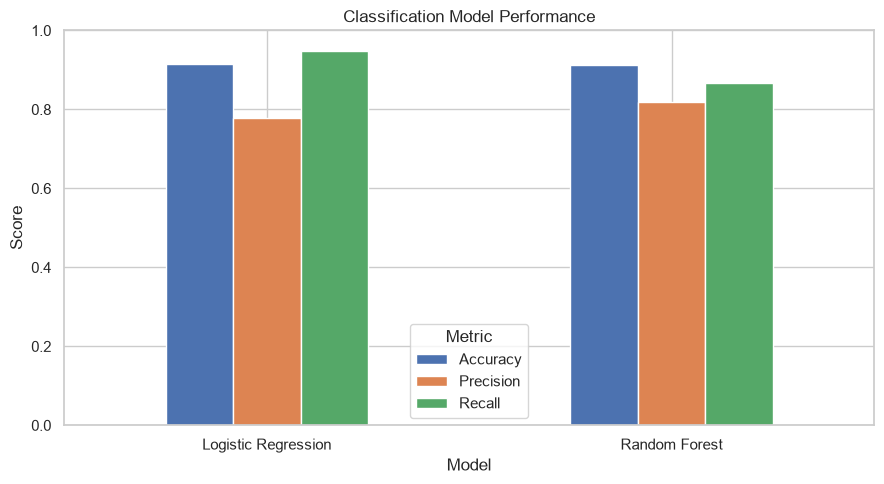

In [24]:
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Classification Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

### Classification Model Comparison

Both classification models achieved strong and very similar overall accuracy. Logistic Regression reached an accuracy of 91.5%, while Random Forest achieved 91.4%.

Logistic Regression obtained a precision of 77.9% and a recall of 94.8%. This means that the model successfully identified nearly 95% of the customers who actually churned, although some active customers were incorrectly classified as being at risk.

Random Forest achieved a higher precision of 81.8%, meaning that its churn predictions were more accurate. However, its recall was lower at 86.8%, so it failed to identify a larger number of customers who eventually canceled their memberships.

For this business problem, recall is especially important because failing to identify a customer who is likely to leave may prevent the company from applying a retention strategy in time. Based on this criterion, Logistic Regression is the preferred model.

Random Forest may still be useful when the business wants to reduce false churn alerts and prioritize customers with a higher probability of cancellation. However, Logistic Regression provides a better balance for proactive retention because it detects a greater proportion of at-risk customers and is easier to interpret.

### 4. Create Customer Clusters
4.1 Prepare the Data for Clustering

In [25]:
# Create the clustering dataset without the target variable
X_cluster = gym.drop("Churn", axis=1)

In [26]:
# Standardize the clustering features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

The target variable `Churn` was excluded before clustering because this stage uses unsupervised learning. The goal is to group customers based only on similarities in their demographic, contractual, and behavioral characteristics.

The features were standardized using `StandardScaler` because clustering algorithms rely on distances between observations. Without standardization, variables with larger numerical ranges could have a disproportionate influence on the resulting clusters.

4.2 Hierarchical Clustering and Dendrogram

In [27]:
# Create the hierarchical clustering linkage matrix
linked = linkage(
    X_cluster_scaled,
    method="ward"
)

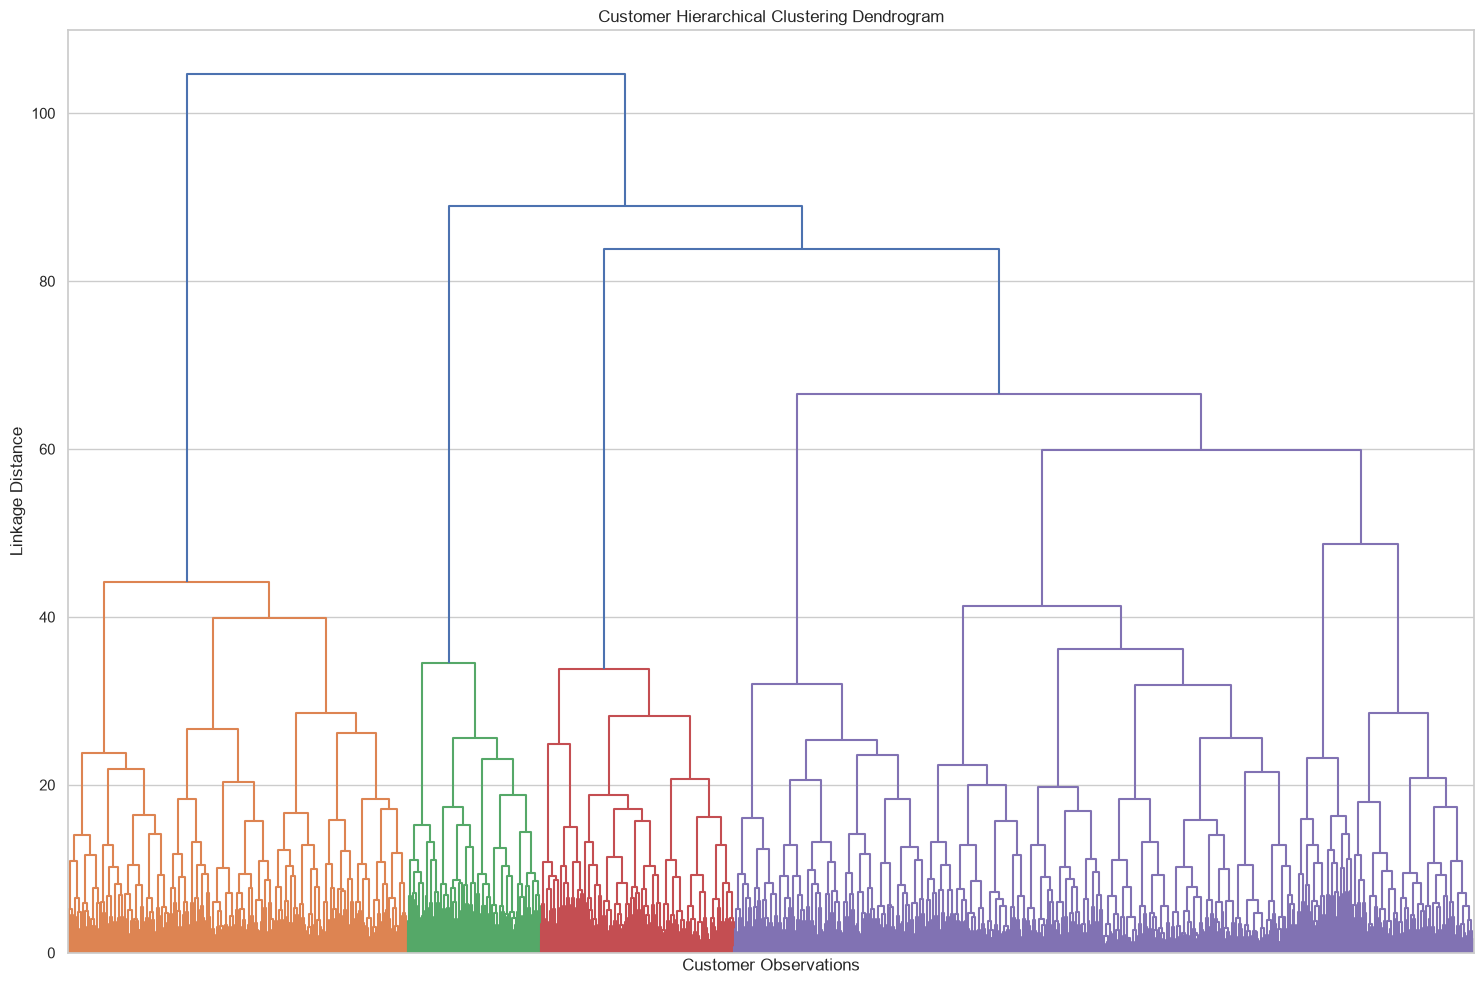

In [28]:
# Plot the dendrogram
plt.figure(figsize=(15, 10))

dendrogram(
    linked,
    orientation="top",
    no_labels=True
)

plt.title("Customer Hierarchical Clustering Dendrogram")
plt.xlabel("Customer Observations")
plt.ylabel("Linkage Distance")
plt.tight_layout()
plt.show()

### Dendrogram Interpretation

The dendrogram illustrates how customers are progressively grouped according to the similarity of their standardized characteristics. Each branch represents either an individual customer or a group of customers, while the height at which branches merge indicates the distance between the groups being combined.

Clusters that merge at lower linkage distances contain customers with relatively similar profiles. In contrast, branches that merge at greater heights represent groups with more distinct characteristics.

The chart shows several differentiated customer groups, although there is no single perfectly clear separation point. The largest increases in linkage distance near the upper section of the dendrogram suggest that the data could reasonably be divided into approximately four or five major clusters.

For consistency with the project methodology and to obtain a sufficiently detailed customer segmentation, five clusters will be created using K-Means. These groups will then be compared according to their demographic characteristics, membership behavior, gym usage, and churn rates.

The dendrogram is used as an exploratory tool rather than as a definitive rule for selecting the number of clusters. The final choice should also consider cluster size, interpretability, and the practical value of the resulting customer profiles.

4.3 Apply K-Means Clustering

In [29]:
# Create the K-Means model with five customer clusters
kmeans = KMeans(
    n_clusters=5,
    random_state=0,
    n_init=10
)

# Assign each customer to a cluster
gym["Cluster"] = kmeans.fit_predict(X_cluster_scaled)

# Review the number of customers in each cluster
gym["Cluster"].value_counts().sort_index()

Cluster
0     545
1     768
2     642
3     937
4    1108
Name: count, dtype: int64

4.4 Average Values by Cluster

In [30]:
# Calculate average values for each customer cluster
cluster_means = (
    gym.groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_means

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
Cluster,,,,,,,,,,,,,,
0,0.50,0.00,0.47,0.08,0.92,2.23,0.21,28.48,133.86,2.09,2.79,1.66,1.47,0.45
1,0.59,0.97,0.26,0.09,0.90,2.81,0.48,30.14,162.01,2.59,5.13,2.88,2.88,0.07
2,0.48,1.00,0.82,1.00,0.90,3.16,0.45,29.22,141.20,2.92,3.71,1.73,1.63,0.25
3,0.50,0.95,0.74,0.49,0.90,11.87,0.55,29.93,164.76,10.87,4.70,2.00,1.99,0.02
4,0.49,1.00,0.24,0.02,0.90,1.99,0.32,28.21,131.19,1.90,2.40,1.27,1.03,0.53


### Average Values by Cluster Interpretation

The average values by cluster reveal five customer profiles with clearly differentiated membership and behavioral characteristics.

Cluster 0 contains customers with longer contracts, more months remaining on their memberships, greater participation in friend referral programs, and a higher proportion of customers connected to partner companies. This group appears to have a strong contractual and commercial relationship with the gym.

Cluster 1 includes customers with medium-length contracts and moderate attendance frequency. A notable characteristic of this group is the lower availability of phone information, which could make direct communication and retention campaigns more difficult.

Cluster 2 primarily includes customers who do not live or work near the gym. These customers also tend to have shorter contracts, lower participation in group classes, and lower attendance frequency. Distance from the gym may represent an important barrier to regular participation.

Cluster 3 contains customers who generally live or work near the gym but have short contracts, short customer lifetimes, and relatively low attendance frequency. This group may represent newer or less engaged customers and could be particularly vulnerable to churn.

Cluster 4 displays the most favorable characteristics. Its customers tend to be older, attend the gym more frequently, spend more on additional services, and have longer customer lifetimes. This group appears to represent the gym's most engaged and loyal members.

4.5 Feature Distributions by Cluster

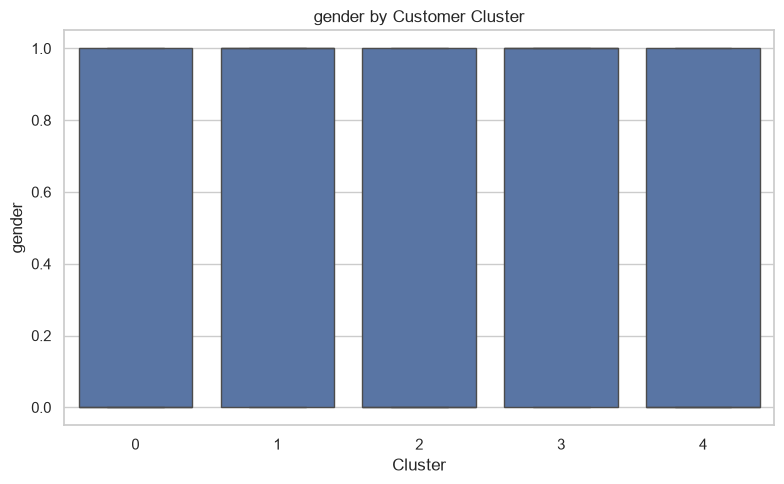

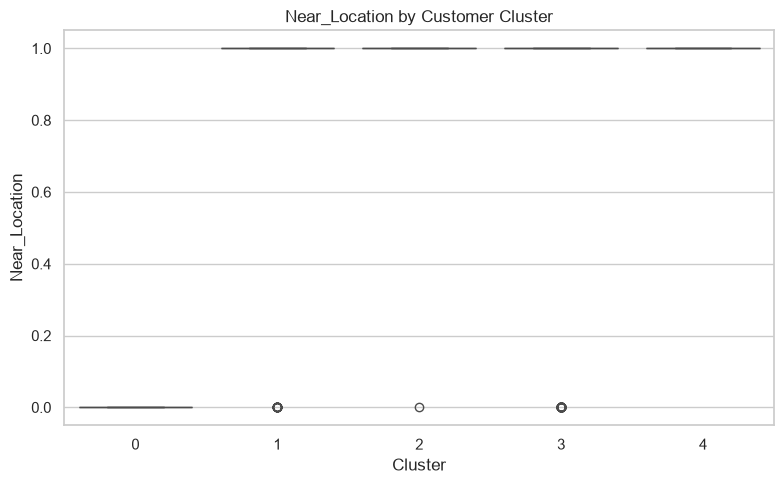

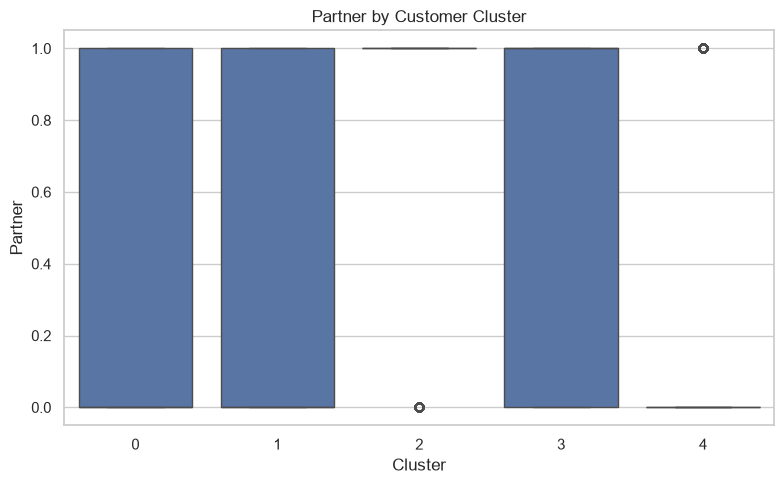

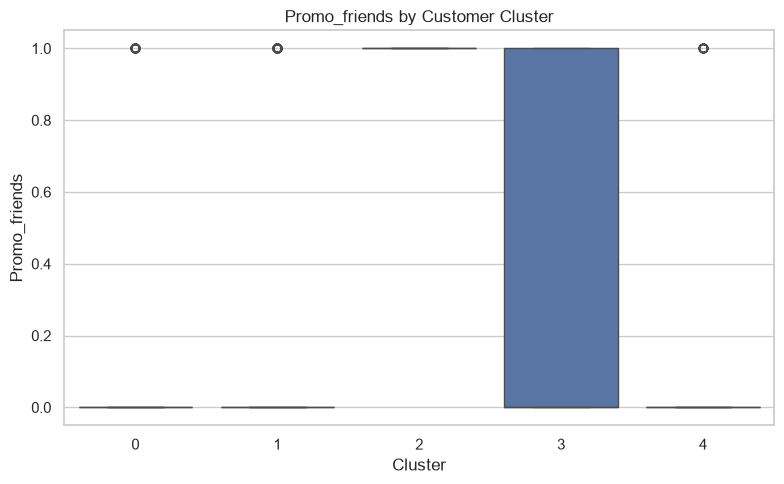

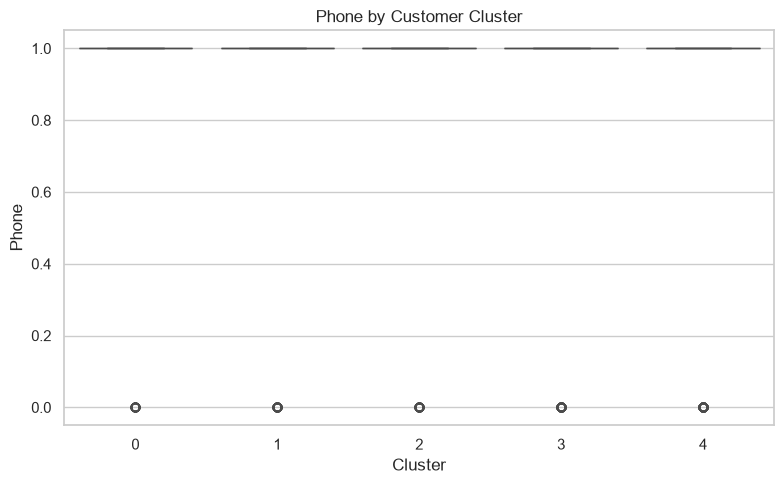

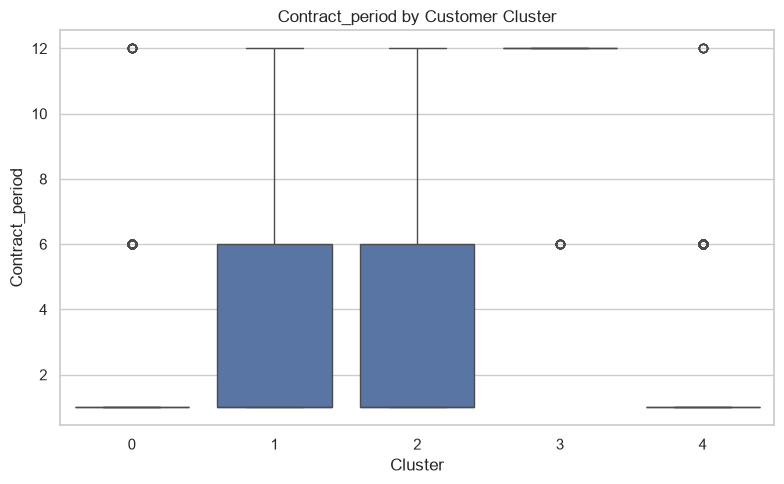

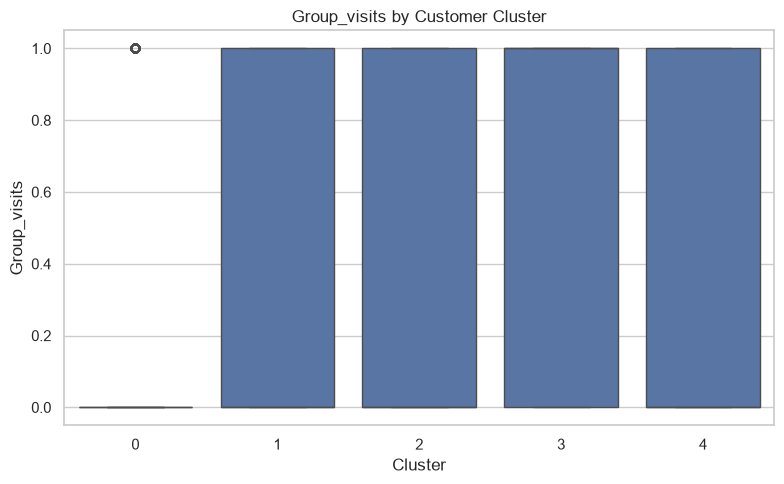

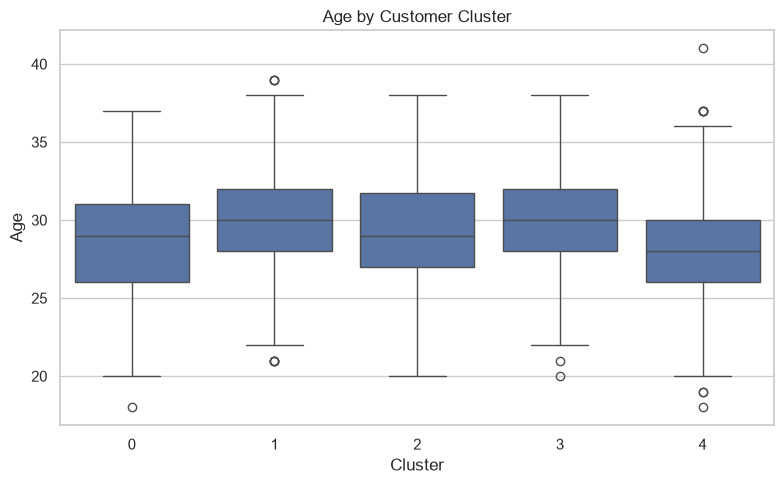

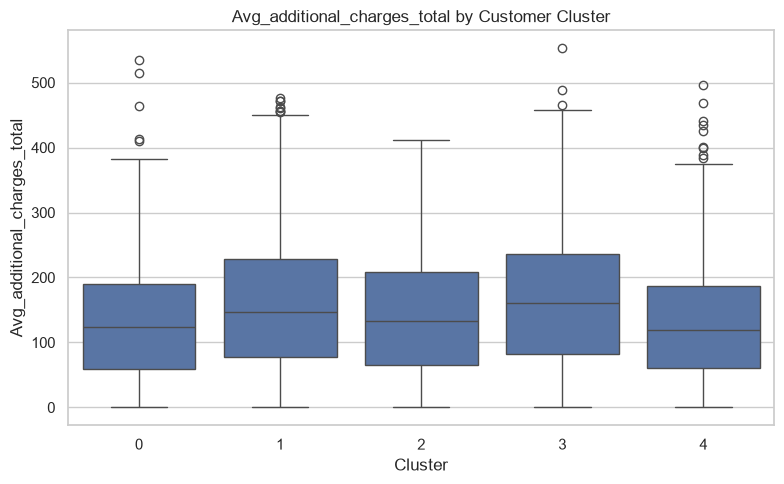

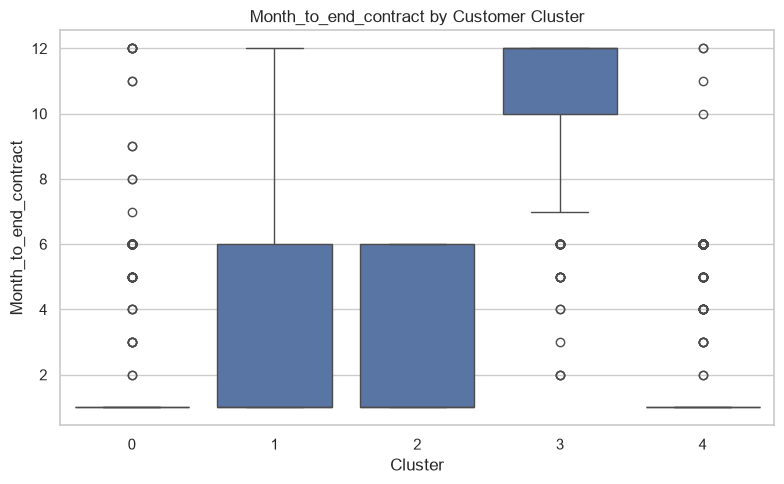

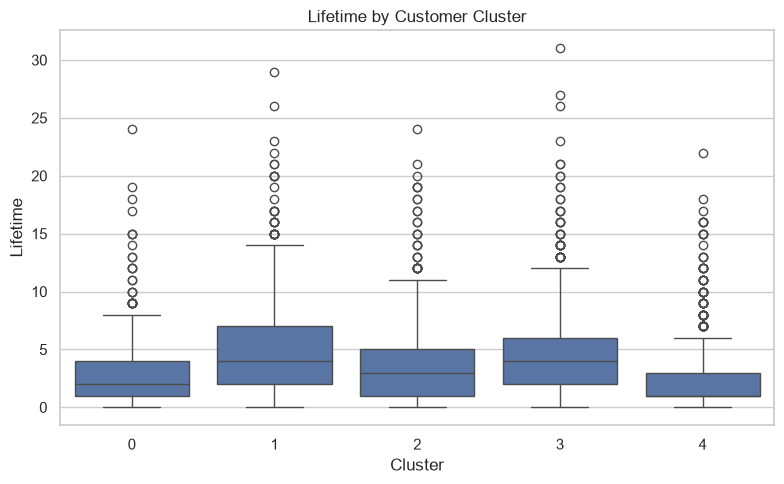

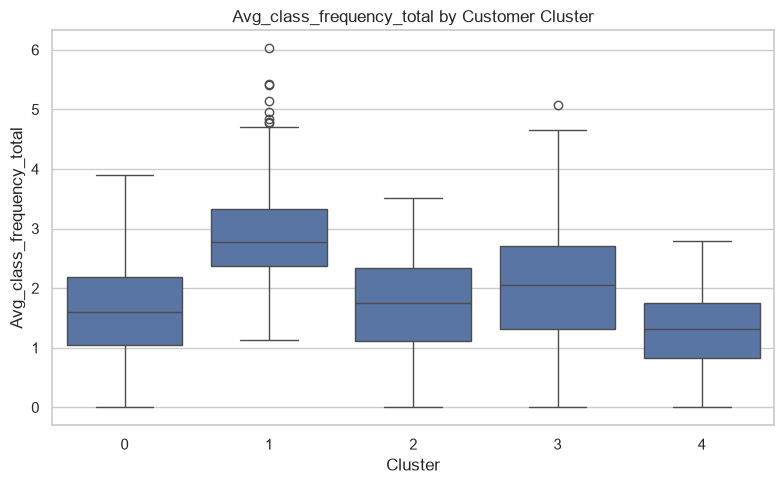

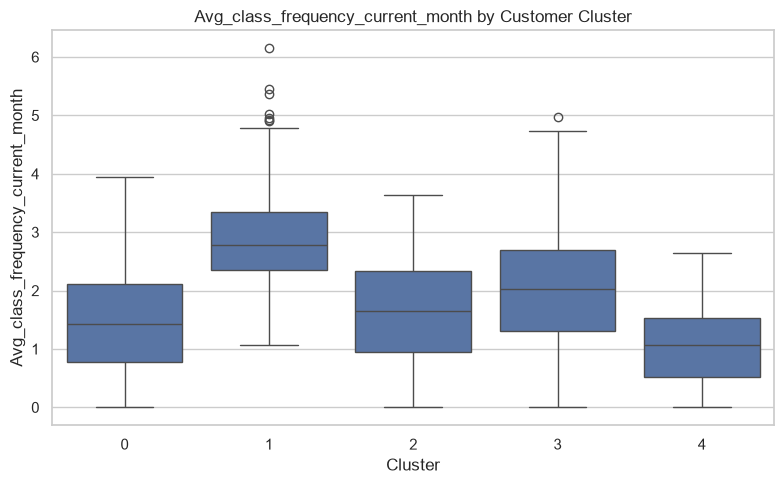

In [31]:
# Select the features to compare across clusters
cluster_features = gym.drop(
    columns=["Churn", "Cluster"]
).columns

# Plot the distribution of each feature by cluster
for column in cluster_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=gym,
        x="Cluster",
        y=column
    )

    plt.title(f"{column} by Customer Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [ ]:
# Binary customer characteristics
binary_features = [
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Group_visits"
]

for column in binary_features:
    cluster_proportions = (
        gym.groupby("Cluster")[column]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=cluster_proportions,
        x="Cluster",
        y=column
    )

    plt.title(f"Proportion of {column} by Customer Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Proportion")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [ ]:
# Continuous and discrete numerical features
numerical_features = [
    "Contract_period",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month"
]

for column in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=gym,
        x="Cluster",
        y=column
    )

    plt.title(f"{column} by Customer Cluster")
    plt.xlabel("Cluster")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

### General Interpretation of Feature Distributions by Cluster

The feature distributions reveal five customer groups with clearly differentiated membership and engagement profiles. Variables such as `gender` and `Phone` remain relatively similar across clusters, suggesting that they contribute little to the segmentation.

Cluster 0 is primarily defined by location. Unlike the other groups, its members generally do not live or work near the gym. They also tend to have short contracts, relatively low group-class participation, and moderate-to-low attendance frequency. Distance from the gym may represent an important barrier to consistent engagement for this group.

Cluster 1 contains some of the most active customers. Its members show the highest historical and current class attendance, relatively longer customer lifetimes, and higher spending on additional services. Contract duration varies within the group, but its strong attendance behavior suggests a comparatively engaged customer profile.

Cluster 2 is strongly associated with partner companies and friend-referral promotions. Nearly all customers in this cluster joined through a referral program, and a large proportion are connected to partner organizations. Their contracts are generally short to medium in length, while attendance and customer lifetime remain moderate.

Cluster 3 shows the strongest contractual commitment. Customers in this group generally have twelve-month contracts, the largest number of months remaining, relatively long customer lifetimes, high participation in group classes, and above-average spending on additional services. Their attendance is also relatively high, although slightly below Cluster 1. These characteristics suggest a stable and highly committed customer segment.

Cluster 4 appears to contain newer and less engaged customers. Its members generally have short contracts, fewer months remaining, shorter customer lifetimes, the lowest class attendance, and relatively low participation in referral and partner programs. This profile may be especially vulnerable to churn.

Overall, the segmentation is mainly influenced by gym proximity, contract duration, customer lifetime, participation in promotional or partner programs, and class attendance. Cluster 3 represents the strongest contractual profile, Cluster 1 shows the highest attendance engagement, and Cluster 4 appears to be the least engaged segment.

4.6 Churn Rate by Customer Cluster

In [ ]:
# Calculate the churn rate for each customer cluster
churn_rate_by_cluster = (
    gym.groupby("Cluster")["Churn"]
    .agg(
        Customers="count",
        Churned_Customers="sum",
        Churn_Rate="mean"
    )
)

# Convert the churn rate to a percentage
churn_rate_by_cluster["Churn_Rate_Percentage"] = (
    churn_rate_by_cluster["Churn_Rate"] * 100
).round(1)

churn_rate_by_cluster

In [ ]:
# Prepare churn-rate percentages for visualization
churn_rate_percentage = (
    gym.groupby("Cluster")["Churn"]
    .mean()
    .mul(100)
    .round(1)
    .sort_index()
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=churn_rate_percentage.index,
    y=churn_rate_percentage.values
)

plt.title("Churn Rate by Customer Cluster")
plt.xlabel("Customer Cluster")
plt.ylabel("Churn Rate (%)")
plt.ylim(
    0,
    max(churn_rate_percentage.max() * 1.2, 10)
)

# Add percentage labels above the bars
for index, value in enumerate(churn_rate_percentage.values):
    ax.text(
        index,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Churn Rate by Customer Cluster Interpretation

The churn rate varies considerably across the five customer clusters, confirming that each segment has a different retention profile.

Cluster 4 has the highest churn rate at approximately 52.6%, making it the highest-risk customer segment. Customers in this cluster tend to have short contracts, fewer months remaining, shorter customer lifetimes, and the lowest historical and current class attendance. They also show relatively low participation in partner and referral programs. These characteristics suggest limited engagement and make this cluster the main priority for retention initiatives.

Cluster 0 has the second-highest churn rate at 45.0%. This group is primarily composed of customers who do not live or work near the gym. They also tend to have short contracts, low group-class participation, and moderate-to-low attendance frequency. Distance from the gym may be an important barrier to regular use and long-term retention.

Cluster 2 has a moderate churn rate of 24.8%. This group is strongly associated with partner companies and friend-referral promotions, but its members generally have short or medium-length contracts and only moderate attendance levels. Although its churn rate is lower than those of Clusters 0 and 4, it should still be monitored.

Clusters 1 and 3 have the lowest churn rates, at approximately 6.9% and 2.2%, respectively. Cluster 1 includes customers with the highest class attendance and relatively longer customer lifetimes, while Cluster 3 is characterized by long-term contracts, more months remaining, higher group-class participation, and stronger overall commitment.

Overall, Clusters 4 and 0 should be prioritized for retention campaigns. Cluster 2 represents a secondary-risk group, while Clusters 1 and 3 can serve as reference profiles for understanding the behaviors associated with stronger customer loyalty.

## Cluster Analysis Conclusion

The cluster analysis identified five customer profiles with clearly differentiated levels of engagement, contractual commitment, and churn risk.

Clusters 4 and 0 represent the highest-risk segments. Cluster 4 is characterized by short contracts, limited customer tenure, low attendance frequency, and weaker participation in partner or referral programs. Cluster 0 is mainly affected by distance from the gym, combined with short contracts and lower engagement.

Cluster 2 presents a moderate churn risk. Although many of its members are connected to partner companies or joined through referral promotions, their contract duration and attendance levels remain relatively limited.

In contrast, Clusters 1 and 3 show the strongest retention profiles. Cluster 1 is distinguished by high attendance frequency and longer customer relationships, while Cluster 3 shows the strongest contractual commitment through longer memberships, more months remaining, and greater participation in group classes.

These findings demonstrate that retention strategies should be segmented rather than applied uniformly. Model Fitness should focus its primary retention efforts on Clusters 4 and 0 through early engagement campaigns, attendance-based alerts, personalized offers, and flexible membership options. Cluster 2 should receive targeted follow-up, while the behaviors observed in Clusters 1 and 3 can help define best practices for customer loyalty.

## 5. Conclusions and Recommendations

The analysis of the Model Fitness dataset identified several important patterns related to customer churn. The dataset contains 4,000 customer records and no missing values, which made it possible to work directly with the available information.

The exploratory analysis showed that churn is more strongly associated with customer behavior and membership characteristics than with demographic variables. Features such as `gender` and `Phone` showed limited differences between customers who stayed and those who churned. In contrast, `Contract_period`, `Month_to_end_contract`, `Lifetime`, `Avg_class_frequency_total`, and `Avg_class_frequency_current_month` showed clear relationships with customer retention.

Customers who churned generally had shorter contracts, fewer months remaining, shorter customer lifetimes, and lower class attendance. Recent attendance was especially important: customers who remained active attended classes more frequently during the current month, while churned customers were concentrated at lower activity levels.

Two classification models were trained to predict customer churn: Logistic Regression and Random Forest. Both models achieved similar overall accuracy. Logistic Regression reached an accuracy of 91.5%, a precision of 77.9%, and a recall of 94.8%. Random Forest achieved an accuracy of 91.4%, a precision of 81.8%, and a recall of 86.8%.

Although Random Forest produced slightly higher precision, Logistic Regression achieved substantially higher recall. Since recall measures the ability to identify customers who are truly at risk of leaving, Logistic Regression is the preferred model for proactive retention efforts. It also provides greater interpretability, making it easier to explain which customer characteristics influence churn predictions.

The cluster analysis identified five customer segments with different engagement and retention profiles. Clusters 4 and 0 showed the highest churn rates, at 52.6% and 45.0%, respectively. Cluster 4 was characterized by short contracts, low attendance, short customer lifetimes, and weaker participation in partner and referral programs. Cluster 0 mainly included customers who did not live or work near the gym and also showed relatively low engagement.

Cluster 2 showed a moderate churn rate of 24.8%, while Clusters 1 and 3 had the lowest churn rates, at 6.9% and 2.2%. Cluster 1 stood out for its high class attendance, while Cluster 3 showed the strongest contractual commitment through longer memberships and more months remaining.

Based on these findings, Model Fitness should prioritize retention efforts for customers with short contracts, low recent attendance, limited tenure, and weak engagement with gym services.

### Specific Recommendations

1. Implement early-retention campaigns for customers with low `Lifetime`, especially during the first months of membership.

2. Monitor `Avg_class_frequency_current_month` to identify customers whose attendance is declining and contact them before they cancel.

3. Promote six- and twelve-month contracts through discounts, added benefits, or corporate packages, since longer contracts are associated with lower churn.

4. Encourage participation in group classes, referral programs, and additional services to strengthen customer engagement.

5. Prioritize retention actions for Clusters 4 and 0, since they show the highest churn rates.

6. Develop location-sensitive strategies for Cluster 0, such as flexible schedules, digital classes, or targeted offers for customers who live farther from the gym.

7. Use Logistic Regression as the primary churn-screening model because its high recall allows the company to identify most at-risk customers.

8. Review false-positive cases separately so that retention resources are not applied too broadly to customers who are likely to remain active.

9. Track customer engagement monthly and create alerts when attendance, class participation, or additional spending decreases significantly.

10. Use the characteristics of Clusters 1 and 3 as reference profiles when designing loyalty programs for less engaged customer segments.